In [1]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
import regina
import numpy as np
from pachner_traversal.data_io_dehydration import Dataset

In [19]:
obj = "edge_degree_variance" # edge_degree_variance, det_alexander, unit_deg, loop_count

res_path = (
    data_root
    / "results"
    / "sgd_models_dehydration"
    / "scalar_simple"
    / obj
    / "spheres_512emb_6block_4head_10tet"
)
processed_data_home = data_root / "input_data" / "dehydration" / "processed"
data_path = processed_data_home / "spheres_10.hdf5"

In [20]:
train_losses = pd.read_csv(res_path / "train_losses.csv", header=None, index_col=0)[1]
test_losses = pd.read_csv(res_path / "test_losses.csv", header=None, index_col=0)[1]

train_losses.index.name = None
test_losses.index.name = None

In [21]:
dataset = Dataset(data_path)

In [22]:
actual_edv = dataset.read_all_data(dset_name=obj)
actual_edv = actual_edv - np.mean(actual_edv)
actual_edv = actual_edv / np.std(actual_edv)

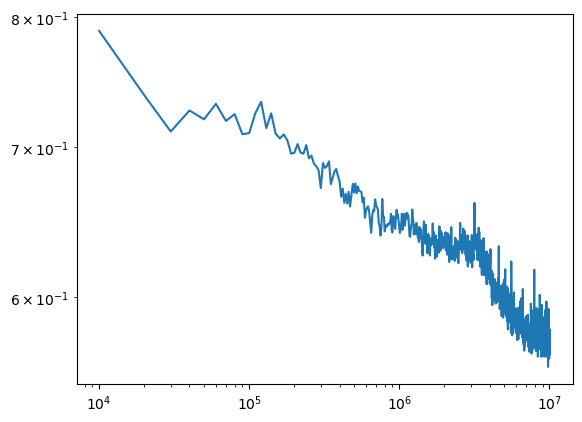

In [27]:
(train_losses / np.var(actual_edv)).plot()
# (test_losses / np.var(actual_edv)).plot()

plt.loglog()
plt.show()

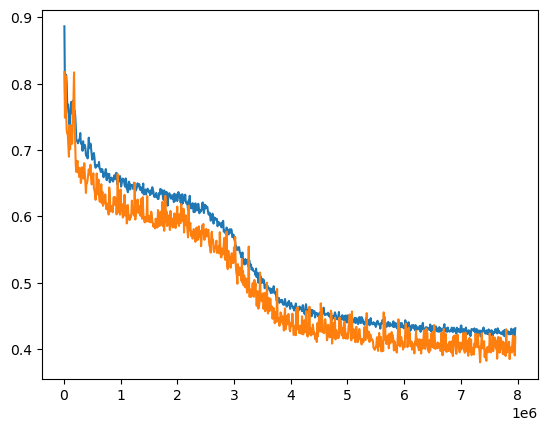

In [6]:
(train_losses / np.var(actual_edv)).plot()
(test_losses / np.var(actual_edv)).plot()

# plt.loglog()
plt.show()